In [1]:
# 📦 Install required libraries (if not already installed)
!pip install pandas requests tqdm scikit-learn seaborn matplotlib


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: C:\Users\Udarata Computers\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [2]:
%pip install sklearn
%pip install scikit-learn matplotlib
%pip install seaborn

# 🧠 Imports
import pandas as pd
import requests
import json
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

# ---------------- CONFIG ----------------
OLLAMA_API = "http://localhost:11434/api/generate"  
MODEL = "llama3"  

# ⚙️ Path to the pre-sampled 1000-row dataset
CSV_PATH = r"C:\Users\Udarata Computers\OneDrive\Desktop\Intent Classification-Data\Test_Sample_1000.csv"

# ---------------- LOAD DATA ----------------
if not os.path.isfile(CSV_PATH):
    raise FileNotFoundError(f"❌ File not found: {CSV_PATH}\nPlease check the path and ensure the file exists.")

# ✅ Load the fixed 1000-sample dataset
df = pd.read_csv(CSV_PATH)
assert "text" in df.columns and "intent" in df.columns, "CSV must have 'text' and 'intent' columns"

print(f"✅ Loaded pre-sampled dataset with {len(df)} rows for evaluation")

# Extract all unique intents
INTENTS = sorted(df["intent"].unique().tolist())
print("📌 Detected intents:", INTENTS)


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ Loaded pre-sampled dataset with 1000 rows for evaluation
📌 Detected intents: ['AddToPlaylist', 'BookRestaurant', 'GetWeather', 'PlayMusic', 'RateBook', 'SearchCreativeWork', 'SearchScreeningEvent', 'cancel_order', 'change_order', 'change_shipping_address', 'check_cancellation_fee', 'check_invoice', 'check_payment_methods', 'check_refund_policy', 'complaint', 'contact_customer_service', 'contact_human_agent', 'create_account', 'delete_account', 'delivery_options', 'delivery_period', 'edit_account', 'get_invoice', 'get_refund', 'newsletter_subscription', 'payment_issue', 'place_order', 'recover_password', 'registration_problems', 'review', 'set_up_shipping_address', 'switch_account', 'track_order', 'track_refund']


In [3]:
def classify_intent_llm(query: str) -> str:
    prompt = f"""
You are an intent classifier. Your task is to classify the following user message into one of these intents:
{', '.join(INTENTS)}

User message: "{query}"

Respond with ONLY the intent name from the list above.
"""
    try:
        payload = {
            "model": MODEL,
            "prompt": prompt,
            "temperature": 0
        }

        # Stream response from Ollama
        response = requests.post(OLLAMA_API, json=payload, stream=True)
        response.raise_for_status()

        # Parse NDJSON stream
        full_output = ""
        for line in response.iter_lines():
            if line:
                data = json.loads(line.decode("utf-8"))
                if "response" in data:
                    full_output += data["response"]

        prediction = full_output.strip().lower().replace("intent:", "").strip()
        if prediction not in [i.lower() for i in INTENTS]:
            prediction = "unknown"
        return prediction

    except Exception as e:
        print("⚠️ Ollama API error:", e)
        return "unknown"


In [4]:
preds = []
for text in tqdm(df["text"], desc="🔎 Evaluating with LLaMA 3 (1000 samples)"):
    preds.append(classify_intent_llm(text))

df["predicted"] = preds


🔎 Evaluating with LLaMA 3 (1000 samples): 100%|██████████| 1000/1000 [4:35:28<00:00, 16.53s/it]     


In [5]:
report = classification_report(
    df["intent"].str.lower(),
    df["predicted"],
    labels=[i.lower() for i in INTENTS],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df.head(15))  # show first 15 rows for readability


,precision,recall,f1-score,support
addtoplaylist,1.000000,0.882353,0.937500,51.0
bookrestaurant,0.980769,1.000000,0.990291,51.0
getweather,1.000000,0.982143,0.990991,56.0
playmusic,0.625000,1.000000,0.769231,45.0
ratebook,1.000000,0.926829,0.962025,41.0
searchcreativework,0.754717,0.689655,0.720721,58.0
searchscreeningevent,0.977778,0.800000,0.880000,55.0
cancel_order,0.793103,0.958333,0.867925,24.0
change_order,0.857143,0.375000,0.521739,16.0
change_shipping_address,0.730769,0.950000,0.826087,20.0


c:\Users\Udarata Computers\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


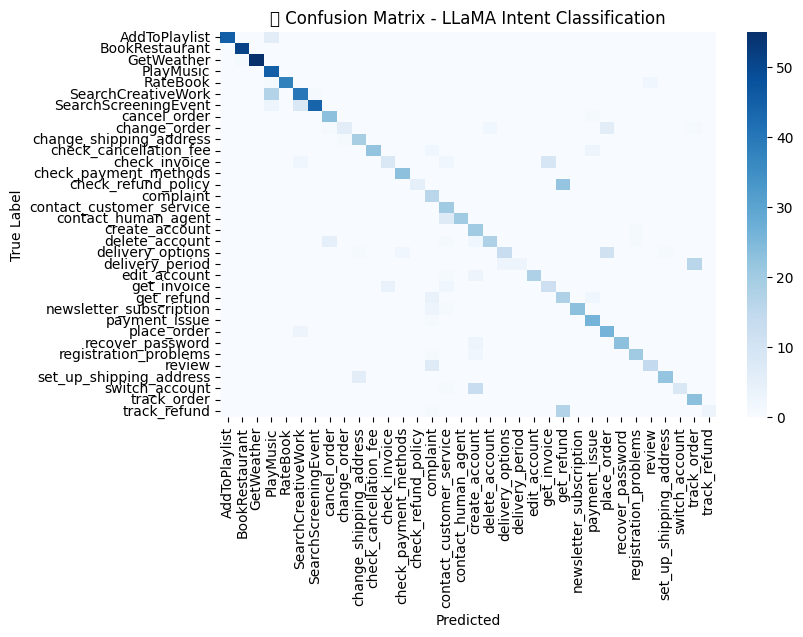

In [6]:
cm = confusion_matrix(df["intent"].str.lower(), df["predicted"], labels=[i.lower() for i in INTENTS])

plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=INTENTS, yticklabels=INTENTS)
plt.title("🔍 Confusion Matrix - LLaMA Intent Classification")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


c:\Users\Udarata Computers\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


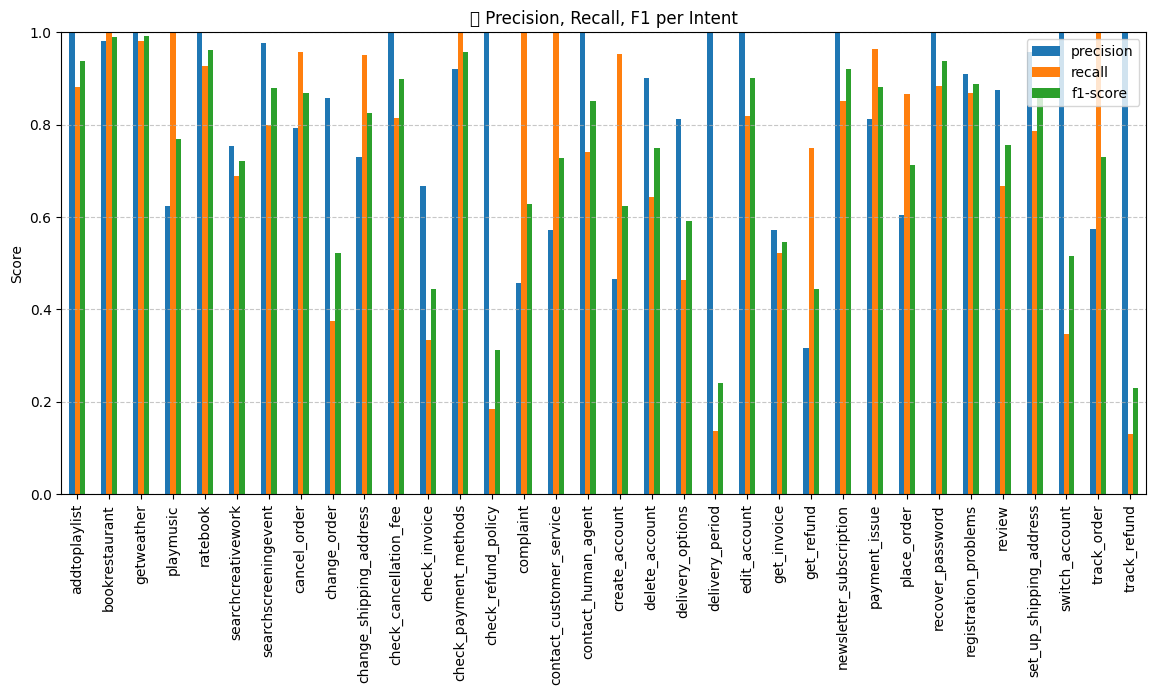

In [7]:
# ✅ Lowercase the INTENTS list to match the report_df index
intent_labels = [i.lower() for i in INTENTS if i.lower() in report_df.index]

# ✅ Slice the dataframe
metrics = report_df.loc[intent_labels, ["precision", "recall", "f1-score"]]

# ✅ Plot
metrics.plot(kind="bar", figsize=(14, 6))
plt.title("📊 Precision, Recall, F1 per Intent")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [8]:
df.to_csv("llama3_predictions_1000.csv", index=False)
print("✅ Results saved to llama3_predictions_1000.csv")


✅ Results saved to llama3_predictions_1000.csv
